In [2]:
import numpy as np
import obspy
import matplotlib.pyplot as plt
import glob
import obspy.imaging.spectrogram
import obspy.taup
import matplotlib as mlab
import pandas as pd
from obspy import read
from obspy import UTCDateTime
from scipy.signal import spectrogram
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import signal
import matplotlib.patches as patches
obspy.__version__

'1.4.2'

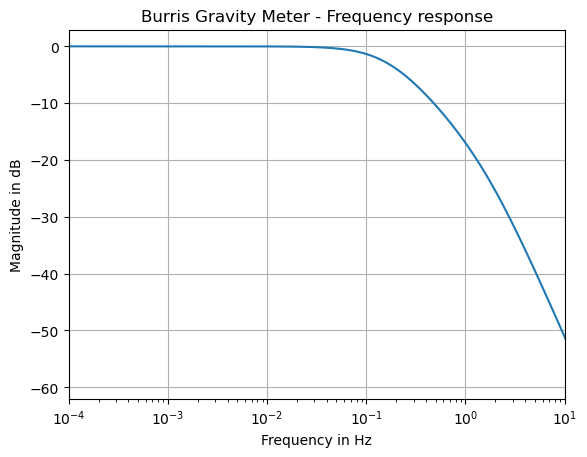

In [3]:
# Transfer function coefficients
num = [1]
den = [0.09, 1.05, 1]

system = signal.TransferFunction(num, den)

# Frequency response
w, mag, phase = signal.bode(system)

w = np.logspace(-4, 2, 1000) # frequency range (rad/s)
w, mag, phase = signal.bode(system, w=w)

plt.semilogx(w/(2*np.pi), mag)
plt.xlim(0.0001, 10)
plt.xlabel("Frequency in Hz")
plt.ylabel("Magnitude in dB")
plt.title("Burris Gravity Meter - Frequency response")
plt.grid(True)

16
2025-12-17T08:22:31.000000Z 2026-01-04T23:59:59.000000Z
1.0
3.837939743043369


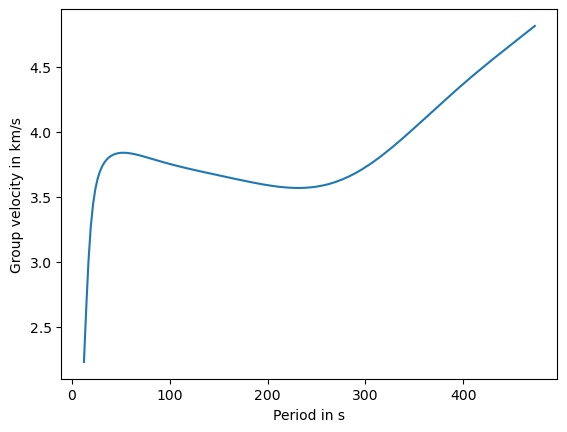

In [4]:
## read mseed data via obspy
stream = read("data/combi_data_20260105.mseed")
tr = stream[-1]
print(len(stream))
print(tr.stats.starttime, tr.stats.endtime)
print(tr.stats.delta)
# -> 16 streams with different length

# read surface wave group velocities for specific periods from .txt
surf_vels = np.loadtxt("data/rayleigh_velocities_2.txt", usecols=(5, 6))
# iterpolate values to gat a function V(T)
V_interp = interp1d(surf_vels[:,0], surf_vels[:,1], bounds_error=False, fill_value="extrapolate")
print(V_interp(50))
T_plot = np.linspace(min(surf_vels[:,0]), max(surf_vels[:,0]), 200)
V_plot = V_interp(T_plot)

plt.plot(T_plot, V_plot)
plt.xlabel("Period in s")
plt.ylabel("Group velocity in km/s")
plt.show()

## Seismological analysis

In [5]:
# calculate arrival datetimes for each event
# write data in new cartalog

cat = obspy.read_events('data/earthquakes2025_5.5+.quakeml') # 14 eqs above magnitude7, From 20.3.25-4.1.26
institute = 10.11997269613289, 54.33991743432981
earth_rad = 6371
taup_model = obspy.taup.TauPyModel()
phase_list = ["P","PP","PPP","PPPP"]
phase_list_S = ["S","SS","SSS","SSSS"]

new_catalog = [] # catalog that contains dictionaries with relevant info for each event
# body waves
first_arrival = np.zeros(len(cat)) # time in sec that the wave needs to propagate
first_arr_datetime = [] # 2D list containing: [origin.times, DateTimes when the waves approach the gravimeter]
first_arrival_S = np.zeros(len(cat))
first_arr_datetime_S = []
dist_deg_P = np.zeros(len(cat))
dist_deg_S = np.zeros(len(cat))
dist_surface_km = np.zeros(len(cat))
#Surface waves:
Tmax, Tmin = 470, 12 # periods. Dispersion: higher period -> lower freq -> slower surface wave
num_bands = 12 # number of log equally spaced freq bands
T_edges = np.logspace(np.log10(Tmax), np.log10(Tmin), num_bands + 1) # edges for frequency bands
T_centers = 0.5 * (T_edges[:-1] + T_edges[1:]) # band centers
first_arrival_Surf = np.zeros((len(cat), num_bands))
first_arr_datetime_Surf = np.empty((len(cat), num_bands), dtype=object)

for i,ev in enumerate(cat):
    origin = ev.origins[0] # get info about earthquake origin
    arrivals = taup_model.get_travel_times_geo(origin.depth/1000,origin.latitude,origin.longitude,institute[1],institute[0],phase_list)
    first_arrival[i] = arrivals[0].time # time of very first arrival (usually 'P' or 'PP')
    dist_deg_P[i] = arrivals[0].distance # distance in degree!
    dist_surface_km[i] = 2 * np.pi * earth_rad * (dist_deg_P[i]/360)  # calculate surface distance in km
    first_arr_datetime.append([origin.time, origin.time + first_arrival[i]])

    arrivals_S = taup_model.get_travel_times_geo(origin.depth/1000,origin.latitude,origin.longitude,institute[1],institute[0],phase_list_S)
    first_arrival_S[i] = arrivals_S[0].time
    first_arr_datetime_S.append([origin.time, origin.time + first_arrival_S[i]])
    dist_deg_S[i]= arrivals[0].distance # would be same dist as for P-waves

    for j in range(num_bands):
        first_arrival_Surf[i, j] = dist_surface_km[i] / V_interp(T_centers[j])
        first_arr_datetime_Surf[i,j] = origin.time + first_arrival_Surf[i,j]
    
    event_info = {
        "name": ev.event_descriptions[0].text if ev.event_descriptions else None, # checks if a name exists
        "origin_dtime": origin.time,
        "origin_depth": origin.depth,
        "origin_lat": origin.latitude,
        "origin_lon": origin.longitude,
        "magnitude": ev.magnitudes[0].mag,
        "distance_deg_P": dist_deg_P[i],
        #"distance_deg_S": dist_deg_S[i],
        "distance_surface_km": dist_surface_km[i],
        "arrival_dtime_P": origin.time + first_arrival[i],
        "first_arrival_P": first_arrival[i],
        "first_arrival_P_phase": arrivals[0].phase.name,
        "arrival_dtime_S": origin.time + first_arrival_S[i],
        "first_arrival_S": first_arrival_S[i],
        "first_arrival_S_phase": arrivals_S[0].phase.name,
        "arrivals_dtime_Surf": first_arr_datetime_Surf[i,:],
        "first_arrivals_Surf": first_arrival_Surf[i,:],
        "Surf_periods": T_centers
    }
    new_catalog.append(event_info)

In [6]:
# settings for Energy calculation:
tr_length_P = 100
tr_length_S = 100
tr_length_Surf = 200
tr_offset = 0 # not needed, can stay 0
tr_length_ref = 200 # reference trace where no earthquake happens -> to calculate ratio
tr_offset_ref = - 1200
window_pre_start = 1/5 # how much of the window lies before the event start -> 1/3=33% -> 67% are behind event start
#T_edges = np.logspace(np.log10(Tmax), np.log10(Tmin), num_bands + 1) # edges for frequency bands
#T_centers = 0.5 * (T_edges[:-1] + T_edges[1:]) # band centers

In [7]:
# code for Energy calculation: calculate mean squared amplitude (signal energy) of event
# writes data as event dictionary in catalog

for i, event in enumerate(new_catalog):
    arrival_dtime_P = event["arrival_dtime_P"]
    arrival_dtime_S = event["arrival_dtime_S"]
    arrival_dtime_Surf = event["arrivals_dtime_Surf"] # 1 value for each band
    start_P = arrival_dtime_P + tr_offset
    start_S = arrival_dtime_S + tr_offset
    start_Surf = arrival_dtime_Surf + tr_offset
    start_ref = arrival_dtime_P + tr_offset_ref
    P_window = [start_P-tr_length_P*window_pre_start, start_P+tr_length_P*(1-window_pre_start)]
    S_window = [start_S-tr_length_S*window_pre_start, start_S+tr_length_S*(1-window_pre_start)]
    #end_P = start_P + tr_length_P
    #end_S = start_S + tr_length_S
    end_ref = start_ref + tr_length_ref
    subset_P = stream.slice(starttime=P_window[0], endtime=P_window[1]) # time window for energy calculation
    subset_S = stream.slice(starttime=S_window[0], endtime=S_window[1])
    subset_ref = stream.slice(starttime=start_ref, endtime=end_ref) # reference energy window

    # surface waves:
    tr_energies_Surf = np.zeros(len(start_Surf))
    tr_energies_ref_band = np.zeros(len(start_Surf))
    for j in range(len(start_Surf)):
        Surf_window = [start_Surf[j]-tr_length_Surf*window_pre_start, start_Surf[j]+tr_length_Surf*(1-window_pre_start)]
        subset_Surf = stream.slice(starttime=Surf_window[0], endtime=Surf_window[1])
        if not subset_Surf:
            tr_energy_Surf = np.nan
            tr_energy_ref_band = np.nan
        else:
            tr_proc_Surf = subset_Surf[0].copy()     # in case there are multiple traces in the subset it takes the first one
            tr_proc_Surf.detrend()
            freqmin = 1 / T_edges[j]
            freqmax = 1 / T_edges[j+1]
            tr_proc_Surf.filter("bandpass", freqmin=freqmin, freqmax=freqmax, zerophase=True) # get freq band for Energy calc
            data_Surf = tr_proc_Surf.data            # np array
            tr_energy_Surf = np.sum(data_Surf**2)/tr_length_Surf # calculation
            # same for reference bands
            tr_proc_ref_band = subset_ref[0].copy()     # in case there are multiple traces in the subset it takes the first one
            tr_proc_ref_band.detrend()
            tr_proc_ref_band.filter("bandpass", freqmin=freqmin, freqmax=freqmax, zerophase=True) # get freq band for Energy calc
            data_ref_band = tr_proc_ref_band.data            # np array
            tr_energy_ref_band = np.sum(data_ref_band**2)/tr_length_ref # calculation
        
        tr_energies_Surf[j] = tr_energy_Surf
        tr_energies_ref_band[j] = tr_energy_ref_band
    
    if not subset_P:
        #print(f"Event {i}: No P data in this interval")
        tr_energy_P = np.nan
    else:
        tr_proc_P = subset_P[0].copy()     # in case there are multiple traces in the subset it takes the first one
        tr_proc_P.detrend()
        tr_proc_P.filter("highpass", freq=0.0005)
        data_P = tr_proc_P.data            # np array
        tr_energy_P = np.sum(data_P**2)/tr_length_P # calculation
        #print(f"Energy P: {tr_energy_P}")
        
    if not subset_S:
        #print(f"Event {i}: No S data in this interval")
        tr_energy_S = np.nan
    else:
        tr_proc_S = subset_S[0].copy()     # in case there are multiple traces in the subset it takes the first one
        tr_proc_S.detrend()
        tr_proc_S.filter("highpass", freq=0.0005)
        data_S = tr_proc_S.data            # np array
        tr_energy_S = np.sum(data_S**2)/tr_length_S # calculation
        #print(f"Energy S: {tr_energy_S}")

    if not subset_ref:
        #print(f"Event {i}: No reference data in this interval")
        tr_energy_ref = np.nan
    else:
        tr_proc_ref = subset_ref[0].copy()     # in case there are multiple traces in the subset it takes the first one
        tr_proc_ref.detrend()
        tr_proc_ref.filter("highpass", freq=0.0005)
        data_ref = tr_proc_ref.data            # np array
        tr_energy_ref = np.sum(data_ref**2)/tr_length_ref # calculation of reference energy

    energy_ratio_P = tr_energy_P / tr_energy_ref # calculate ratio of earthquake to silence
    energy_ratio_S = tr_energy_S / tr_energy_ref
    energy_ratios_Surf_full = tr_energies_Surf / tr_energy_ref
    energy_ratios_Surf = np.zeros(len(start_Surf))
    for band in range(len(start_Surf)):
        energy_ratios_Surf[band] = tr_energies_Surf[band] / tr_energies_ref_band[band]
        
    new_catalog[i]["energy_P"] = tr_energy_P
    new_catalog[i]["energy_ratio_P"] = np.round(energy_ratio_P, 3)
    new_catalog[i]["energy_S"] = tr_energy_S
    new_catalog[i]["energy_ratio_S"] = np.round(energy_ratio_S, 3)
    new_catalog[i]["energies_Surf"] = tr_energies_Surf
    new_catalog[i]["energy_ratios_Surf"] = energy_ratios_Surf # ratio compared to corresponding freq band od noise
    new_catalog[i]["energy_ratios_Surf_broadNoise"] = energy_ratios_Surf_full # ratio compared to broadband noise

In [8]:
# plot a specific event
event_nr = 2
tr_length = 2100 # length of plotted traces in seconds
tr_offset = -500 # time offset before calculated first arrival in seconds
energy_win_len = 200 # length of the sliding window for energy calculation

#plot add-ons:
show_single_bands = True
band_index0, band_index1 = 5, 7 # bands which energies are specifically plotted
show_p_win = True
show_s_win = True
show_surf_win = True
surf_win_index = 2
show_all_surf_wins = False
show_ref_win = False

Data for event Nr.2 at 2025-03-28T06:20:52.715000Z:


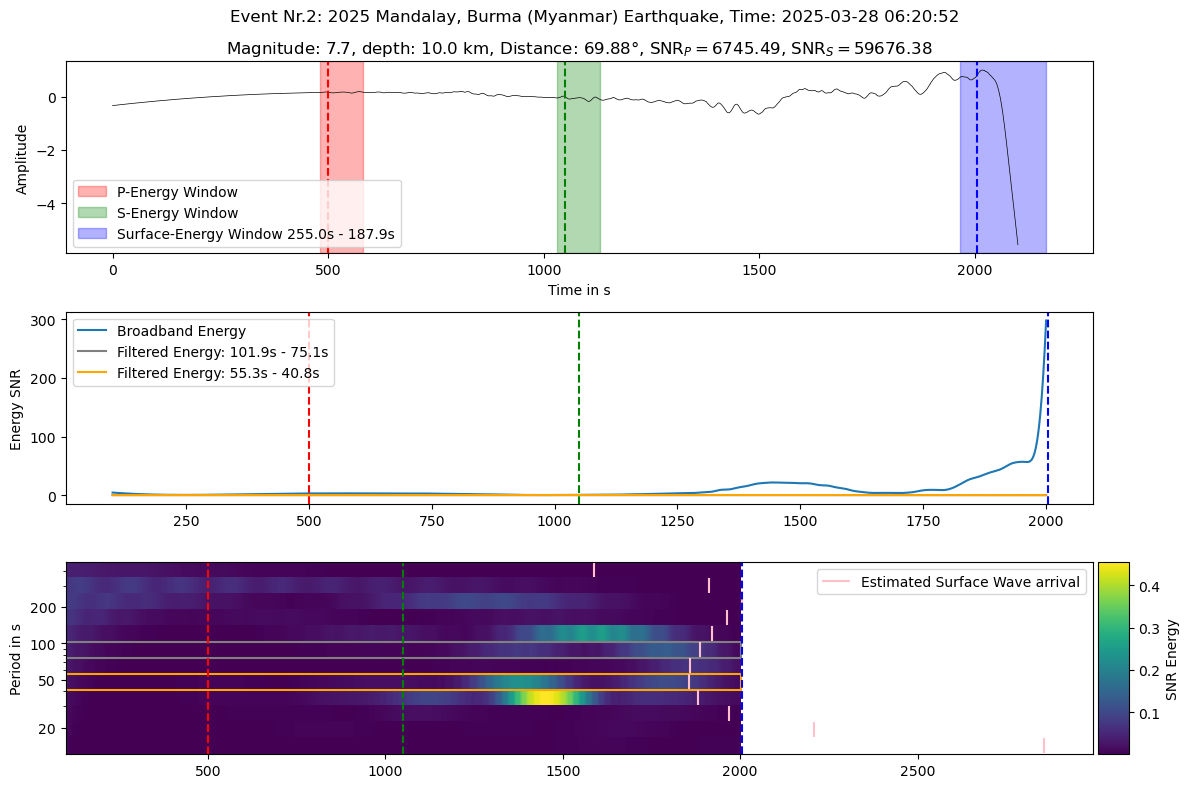

In [9]:
# code for "plot a specific event"
#start = UTCDateTime("2025-04-01T07:19:00")
#end   = UTCDateTime("2025-04-01T07:20:00")
data_exists = False

while data_exists == False:
    origin_dtime = new_catalog[event_nr]["origin_dtime"]
    arrival_dtime = new_catalog[event_nr]["arrival_dtime_P"]
    start = arrival_dtime + tr_offset
    end = start + tr_length
    subset = stream.slice(starttime=start, endtime=end) # trace around event
    
    if not subset:
        print(f"No data for event Nr.{event_nr} at {origin_dtime}")
        event_nr += 1
    else:
        data_exists = True
        eq_name = new_catalog[event_nr]["name"]
        depth = new_catalog[event_nr]["origin_depth"]
        dist_deg = new_catalog[event_nr]["distance_deg_P"]
        magnitude = new_catalog[event_nr]["magnitude"]
        P_ratio = new_catalog[event_nr]["energy_ratio_P"]
        S_ratio = new_catalog[event_nr]["energy_ratio_S"]
        first_arrival_P = new_catalog[event_nr]["first_arrival_P"]
        first_arrival_S = new_catalog[event_nr]["first_arrival_S"]
        first_arrivals_Surf = new_catalog[event_nr]["first_arrivals_Surf"]
        ps_offset = first_arrival_S - first_arrival_P # time between first P and first S
        p_surf_offsets = first_arrivals_Surf - first_arrival_P # times between first P and first Surf for each band
        print(f"Data for event Nr.{event_nr} at {origin_dtime}:")
        tr_proc = subset[0].copy()
        tr_proc.detrend()
        tr_proc.filter("highpass", freq=0.0005, zerophase=True)
        #tr_proc.plot()
        data = tr_proc.data # trace data
        data_norm = data / max(data) # normalize data to +-1
        dt = tr_proc.stats.delta # sample time
        time = np.arange(len(data)) * dt # time vector

        # Windowed Energy time series-------------------------------------------------------------------
        win_len = energy_win_len                 # window length in samples
        shape = (data.size - win_len + 1, win_len) # Create sliding windows (2D view)
        strides = (data.strides[0], data.strides[0])
        windows = np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides) # contains all windows
        energy_array = np.sum(windows**2, axis=1) / win_len  # compute energy per window
        noise_ref = np.median(energy_array[:(-tr_offset)-200]) # median noise energy before first P-event (and in safe distance to it -> 200samples)
        energy_array_norm = energy_array / noise_ref # normalized energy array

        # Filtered Energy map ----------------------------------------------------------------------------
        #T_edges = np.logspace(np.log10(Tmax), np.log10(100), num_bands + 1) # edges for frequency bands
        #T_centers = 0.5 * (T_edges[:-1] + T_edges[1:]) # band center for plotting each band later
        energy_map = np.zeros((num_bands, len(tr_proc.data) - win_len + 1))
        for i in range(num_bands):
            tr_band = tr_proc.copy()
            freqmin = 1 / T_edges[i]
            freqmax = 1 / T_edges[i+1]
            tr_band.filter("bandpass", freqmin=freqmin, freqmax=freqmax, zerophase=True)
            data_band = tr_band.data
            shape_band = (data_band.size - win_len + 1, win_len) # Create sliding windows (2D view)
            strides_band = (data_band.strides[0], data_band.strides[0])
            windows_band = np.lib.stride_tricks.as_strided(data_band, shape=shape_band, strides=strides_band) # contains all windows
            energy_array_band = np.sum(windows_band**2, axis=1) / win_len  # compute energy per window
            energy_array_band_norm = energy_array_band / noise_ref # normalized energy array
            energy_map[i, :] = energy_array_band_norm
        t = (np.arange(len(energy_array_norm)) + win_len/2) * dt # Time axis for plotting (window centers)
        # plots-----------------------------------------------------------------------------------------
        cmap = plt.cm.Blues
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=False, figsize=(12, 8))
        fig.suptitle(f"Event Nr.{event_nr}: {eq_name}, Time: {origin_dtime.strftime('%Y-%m-%d %H:%M:%S')}")
        ax1.plot(time, data_norm, color="black", linewidth=0.5)
        if show_p_win == True:
            ax1.axvspan(-tr_offset-tr_length_P*window_pre_start, -tr_offset+tr_length_P*(1-window_pre_start), color="red", alpha=0.3, label="P-Energy Window") # first P-wave
        if show_s_win == True:
            ax1.axvspan(-tr_offset+ps_offset-tr_length_S*window_pre_start, -tr_offset+ps_offset+tr_length_S*(1-window_pre_start), color="green", alpha=0.3, label="S-Energy Window") # first S-wave
        if show_surf_win == True:
            ax1.axvspan(-tr_offset+p_surf_offsets[surf_win_index]-tr_length_Surf*window_pre_start, -tr_offset+p_surf_offsets[surf_win_index]+tr_length_Surf*(1-window_pre_start), color="blue", alpha=0.3, 
                        label=f"Surface-Energy Window {np.round(T_edges[surf_win_index], 1)}s - {np.round(T_edges[surf_win_index+1],1)}s") # first Surf-waves
        if show_all_surf_wins == True:
            for band in range(len(first_arrivals_Surf)):
                color = cmap((band + 1) / len(first_arrivals_Surf))
                ax1.axvspan(-tr_offset+p_surf_offsets[band]-tr_length_Surf*window_pre_start, -tr_offset+p_surf_offsets[band]+tr_length_Surf*(1-window_pre_start), color=color, alpha=0.1, label="Surface-Energy Window") # first Surf-waves
        if show_ref_win == True:
            ax1.axvspan(-tr_offset+tr_offset_ref, -tr_offset+tr_offset_ref+tr_length_ref, color="yellow", alpha=0.5, label="Noise-Energy Window") # reference window
        ax1.set_ylabel("Amplitude")
        ax1.legend()
        ax1.set_title(rf"Magnitude: {magnitude}, depth: {depth/1000} km, Distance: {np.round(dist_deg, 2)}°, $\mathrm{{SNR}}_P = {np.round(P_ratio, 2)}$, $\mathrm{{SNR}}_S = {np.round(S_ratio, 2)}$")

        ax2.plot(t, energy_array_norm, label="Broadband Energy")
        ax2.set_ylabel("Energy SNR")
        if show_single_bands == True:
            color0, color1 = "grey", "orange"
            ax2.plot(t, energy_map[band_index0, :], color=color0, label=f"Filtered Energy: {np.round(T_edges[band_index0], 1)}s - {np.round(T_edges[band_index0+1],1)}s")
            ax2.plot(t, energy_map[band_index1, :], color=color1, label=f"Filtered Energy: {np.round(T_edges[band_index1], 1)}s - {np.round(T_edges[band_index1+1],1)}s")
        
            T_top0 = T_edges[band_index0]
            T_bot0 = T_edges[band_index0 + 1]
            T_top1 = T_edges[band_index1]
            T_bot1 = T_edges[band_index1 + 1]
            rect0 = patches.Rectangle(
                (t[0], T_bot0),                  # lower-left corner
                width=t[-1] - t[0],                # full time range
                height=T_top0 - T_bot0,           # band thickness
                linewidth=1.5,
                edgecolor=color0,
                facecolor="none"
            )
            rect1 = patches.Rectangle(
                (t[0], T_bot1),                  # lower-left corner
                width=t[-1] - t[0],                # full time range
                height=T_top1 - T_bot1,           # band thickness
                linewidth=1.5,
                edgecolor=color1,
                facecolor="none"
            )
        ax2.legend()
        im = ax3.pcolormesh(t, T_centers, energy_map, shading="auto")
        ax1.set_xlabel("Time in s")
        ax3.set_yscale("log")
        ax3.set_ylabel("Period in s")
        for band in range(len(first_arrivals_Surf)):
            x0 = -tr_offset + p_surf_offsets[band]
            y0 = T_edges[band]
            y1 = T_edges[band+1] * 1.03
            label = "Estimated Surface Wave arrival" if band == 0 else None
            ax3.vlines(x0, y0, y1, color="pink", label=label)
        ax3.set_ylim(T_edges.min(), T_edges.max())
        ax3.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
        ax3.yaxis.set_major_formatter(ScalarFormatter())
        # create dividers for all axes
        divider1 = make_axes_locatable(ax1)
        divider2 = make_axes_locatable(ax2)
        divider3 = make_axes_locatable(ax3)
        # reserve space on the right of all axes for the colorbar
        cax1 = divider1.append_axes("right", size="3%", pad=0.05)
        cax2 = divider2.append_axes("right", size="3%", pad=0.05)
        cax3 = divider3.append_axes("right", size="3%", pad=0.05)
        cax1.axis("off")
        cax2.axis("off")
        im = ax3.pcolormesh(t, T_centers, energy_map, shading="auto")
        fig.colorbar(im, cax=cax3, label="SNR Energy")
        if show_single_bands == True:
            ax3.add_patch(rect0)
            ax3.add_patch(rect1)
        ax3.legend(loc="upper right")

        for ax in (ax1, ax2, ax3):
            if show_p_win == True:
                ax.axvline(-tr_offset, color="red", linestyle="--")
            if show_s_win == True:
                ax.axvline(-tr_offset+ps_offset, color="green", linestyle="--")
            if show_surf_win == True:
                ax.axvline(-tr_offset+p_surf_offsets[surf_win_index], linestyle="--", color="blue") # first Surf-waves
            if show_all_surf_wins == True:
                for band in range(len(first_arrivals_Surf)):
                    color = cmap((band + 1) / len(first_arrivals_Surf))  # values 0–1
                    ax.axvline(-tr_offset+p_surf_offsets[band], linestyle="--", color=color) # first Surf-waves
        
        plt.tight_layout()
        plt.show()

        #fig2 = plt.scatter(amp_max_time, T_values) # something like dispersion curve?
        

In [10]:
# interessante Beben:
"""
20: surface wave mirroring (160°)
9: decent surface wave timing (10bands): Nachbeben 264, 355, 438
2, 24: failure of gravimeter
98: P not detected, but S and Surf very well
"""

'\n20: surface wave mirroring (160°)\n9: decent surface wave timing (10bands): Nachbeben 264, 355, 438\n2, 24: failure of gravimeter\n98: P not detected, but S and Surf very well\n'

In [14]:
# data screening via pandas
pd.set_option("display.max_columns", None)
df = pd.DataFrame(new_catalog[:]) # creates dataframe (table)
#df[df["name"].str.contains("Dra", na=False)]
df
#df["origin_dtime_pd"] = pd.to_datetime(df["origin_dtime"].apply(lambda x: x.datetime))
#df[df["origin_dtime_pd"].dt.date == pd.to_datetime("2025-03-28").date()]

#df[df["distance_deg_P"] > 160]

,name,origin_dtime,origin_depth,origin_lat,origin_lon,magnitude,distance_deg_P,distance_surface_km,arrival_dtime_P,first_arrival_P,first_arrival_P_phase,arrival_dtime_S,first_arrival_S,first_arrival_S_phase,arrivals_dtime_Surf,first_arrivals_Surf,Surf_periods,energy_P,energy_ratio_P,energy_S,energy_ratio_S,energies_Surf,energy_ratios_Surf,energy_ratios_Surf_broadNoise
0,"2025 Kamchatka Peninsula, Russia Earthquake",2025-07-29T23:24:52.483000Z,35000.0,52.4948,160.2395,8.8,70.318301,7819.038377,2025-07-29T23:36:02.431244Z,669.948244,P,2025-07-29T23:45:12.708239Z,1220.225239,S,"[2025-07-29T23:54:21.604670Z, 2025-07-29T23:59...","[1769.1216695662936, 2095.8365057806564, 2189....","[408.11105824991193, 300.632073094186, 221.458...",NaN,NaN,NaN,NaN,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,"140 km E of Petropavlovsk-Kamchatsky, Russia",2025-09-18T18:58:14.939000Z,27000.0,53.1426,160.7206,7.8,69.790897,7760.393687,2025-09-18T19:09:22.797674Z,667.858674,P,2025-09-18T19:18:30.949249Z,1216.010249,S,"[2025-09-18T19:27:30.791827Z, 2025-09-18T19:32...","[1755.8528266445455, 2080.1172221026227, 2173....","[408.11105824991193, 300.632073094186, 221.458...",NaN,NaN,NaN,NaN,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,"2025 Mandalay, Burma (Myanmar) Earthquake",2025-03-28T06:20:52.715000Z,10000.0,22.0110,95.9363,7.7,69.882952,7770.629680,2025-03-28T06:32:03.777002Z,671.062002,P,2025-03-28T06:41:14.300475Z,1221.585475,S,"[2025-03-28T06:50:10.883804Z, 2025-03-28T06:55...","[1758.1688042211438, 2082.860905838515, 2176.4...","[408.11105824991193, 300.632073094186, 221.458...",5.706509e-05,6745.487,5.048469e-04,59676.383,"[7.317694522841188e-13, 1.549549476768192e-11,...","[3361057.848822382, 29145617.008009944, 178059...","[8.650019535977003e-05, 0.0018316743346104686,..."
3,"2025 Aomori Prefecture, Japan Earthquake",2025-12-08T14:15:09.896000Z,40720.0,40.9984,142.1836,7.6,76.216604,8474.899689,2025-12-08T14:26:53.999697Z,704.103697,P,2025-12-08T14:36:35.771805Z,1285.875805,S,"[2025-12-08T14:47:07.411680Z, 2025-12-08T14:53...","[1917.5156796107458, 2271.635371873676, 2373.6...","[408.11105824991193, 300.632073094186, 221.458...",NaN,NaN,NaN,NaN,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,Drake Passage,2025-10-10T20:29:20.075000Z,5639.0,-60.1875,-61.8164,7.6,127.958670,14228.354876,2025-10-10T20:50:29.302729Z,1269.227729,PP,2025-10-10T21:07:44.616124Z,2304.541124,SS,"[2025-10-10T21:22:59.357183Z, 2025-10-10T21:32...","[3219.282182817734, 3813.8072904916235, 3985.1...","[408.11105824991193, 300.632073094186, 221.458...",NaN,NaN,NaN,NaN,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,South Sandwich Islands region,2025-04-05T11:29:12.069000Z,27985.0,-57.2671,-25.6240,5.5,115.316379,12822.596259,2025-04-05T11:48:51.697850Z,1179.628850,PP,2025-04-05T12:04:49.277449Z,2137.208449,SS,"[2025-04-05T12:17:33.286747Z, 2025-04-05T12:26...","[2901.217746835687, 3437.0038927438977, 3591.4...","[408.11105824991193, 300.632073094186, 221.458...",2.944607e-08,2.099,9.244745e-09,0.659,"[1.7584811549403914e-18, 1.1011986573965376e-1...","[16.016159781958905, 0.9662597345652164, 2.830...","[1.253771172920631e-10, 7.851384295042286e-11,..."
446,Reykjanes Ridge,2025-04-05T07:57:09.413000Z,10000.0,52.4880,-32.0879,5.5,24.846984,2762.858548,2025-04-05T08:02:31.923230Z,322.510230,P,2025-04-05T08:06:55.841698Z,586.428698,S,"[2025-04-05T08:07:34.532444Z, 2025-04-05T08:09...","[625.1194444964684, 740.5641877475905, 773.835...","[408

Text(-0.6, 0.5, 'SNR-Threshold = 10')

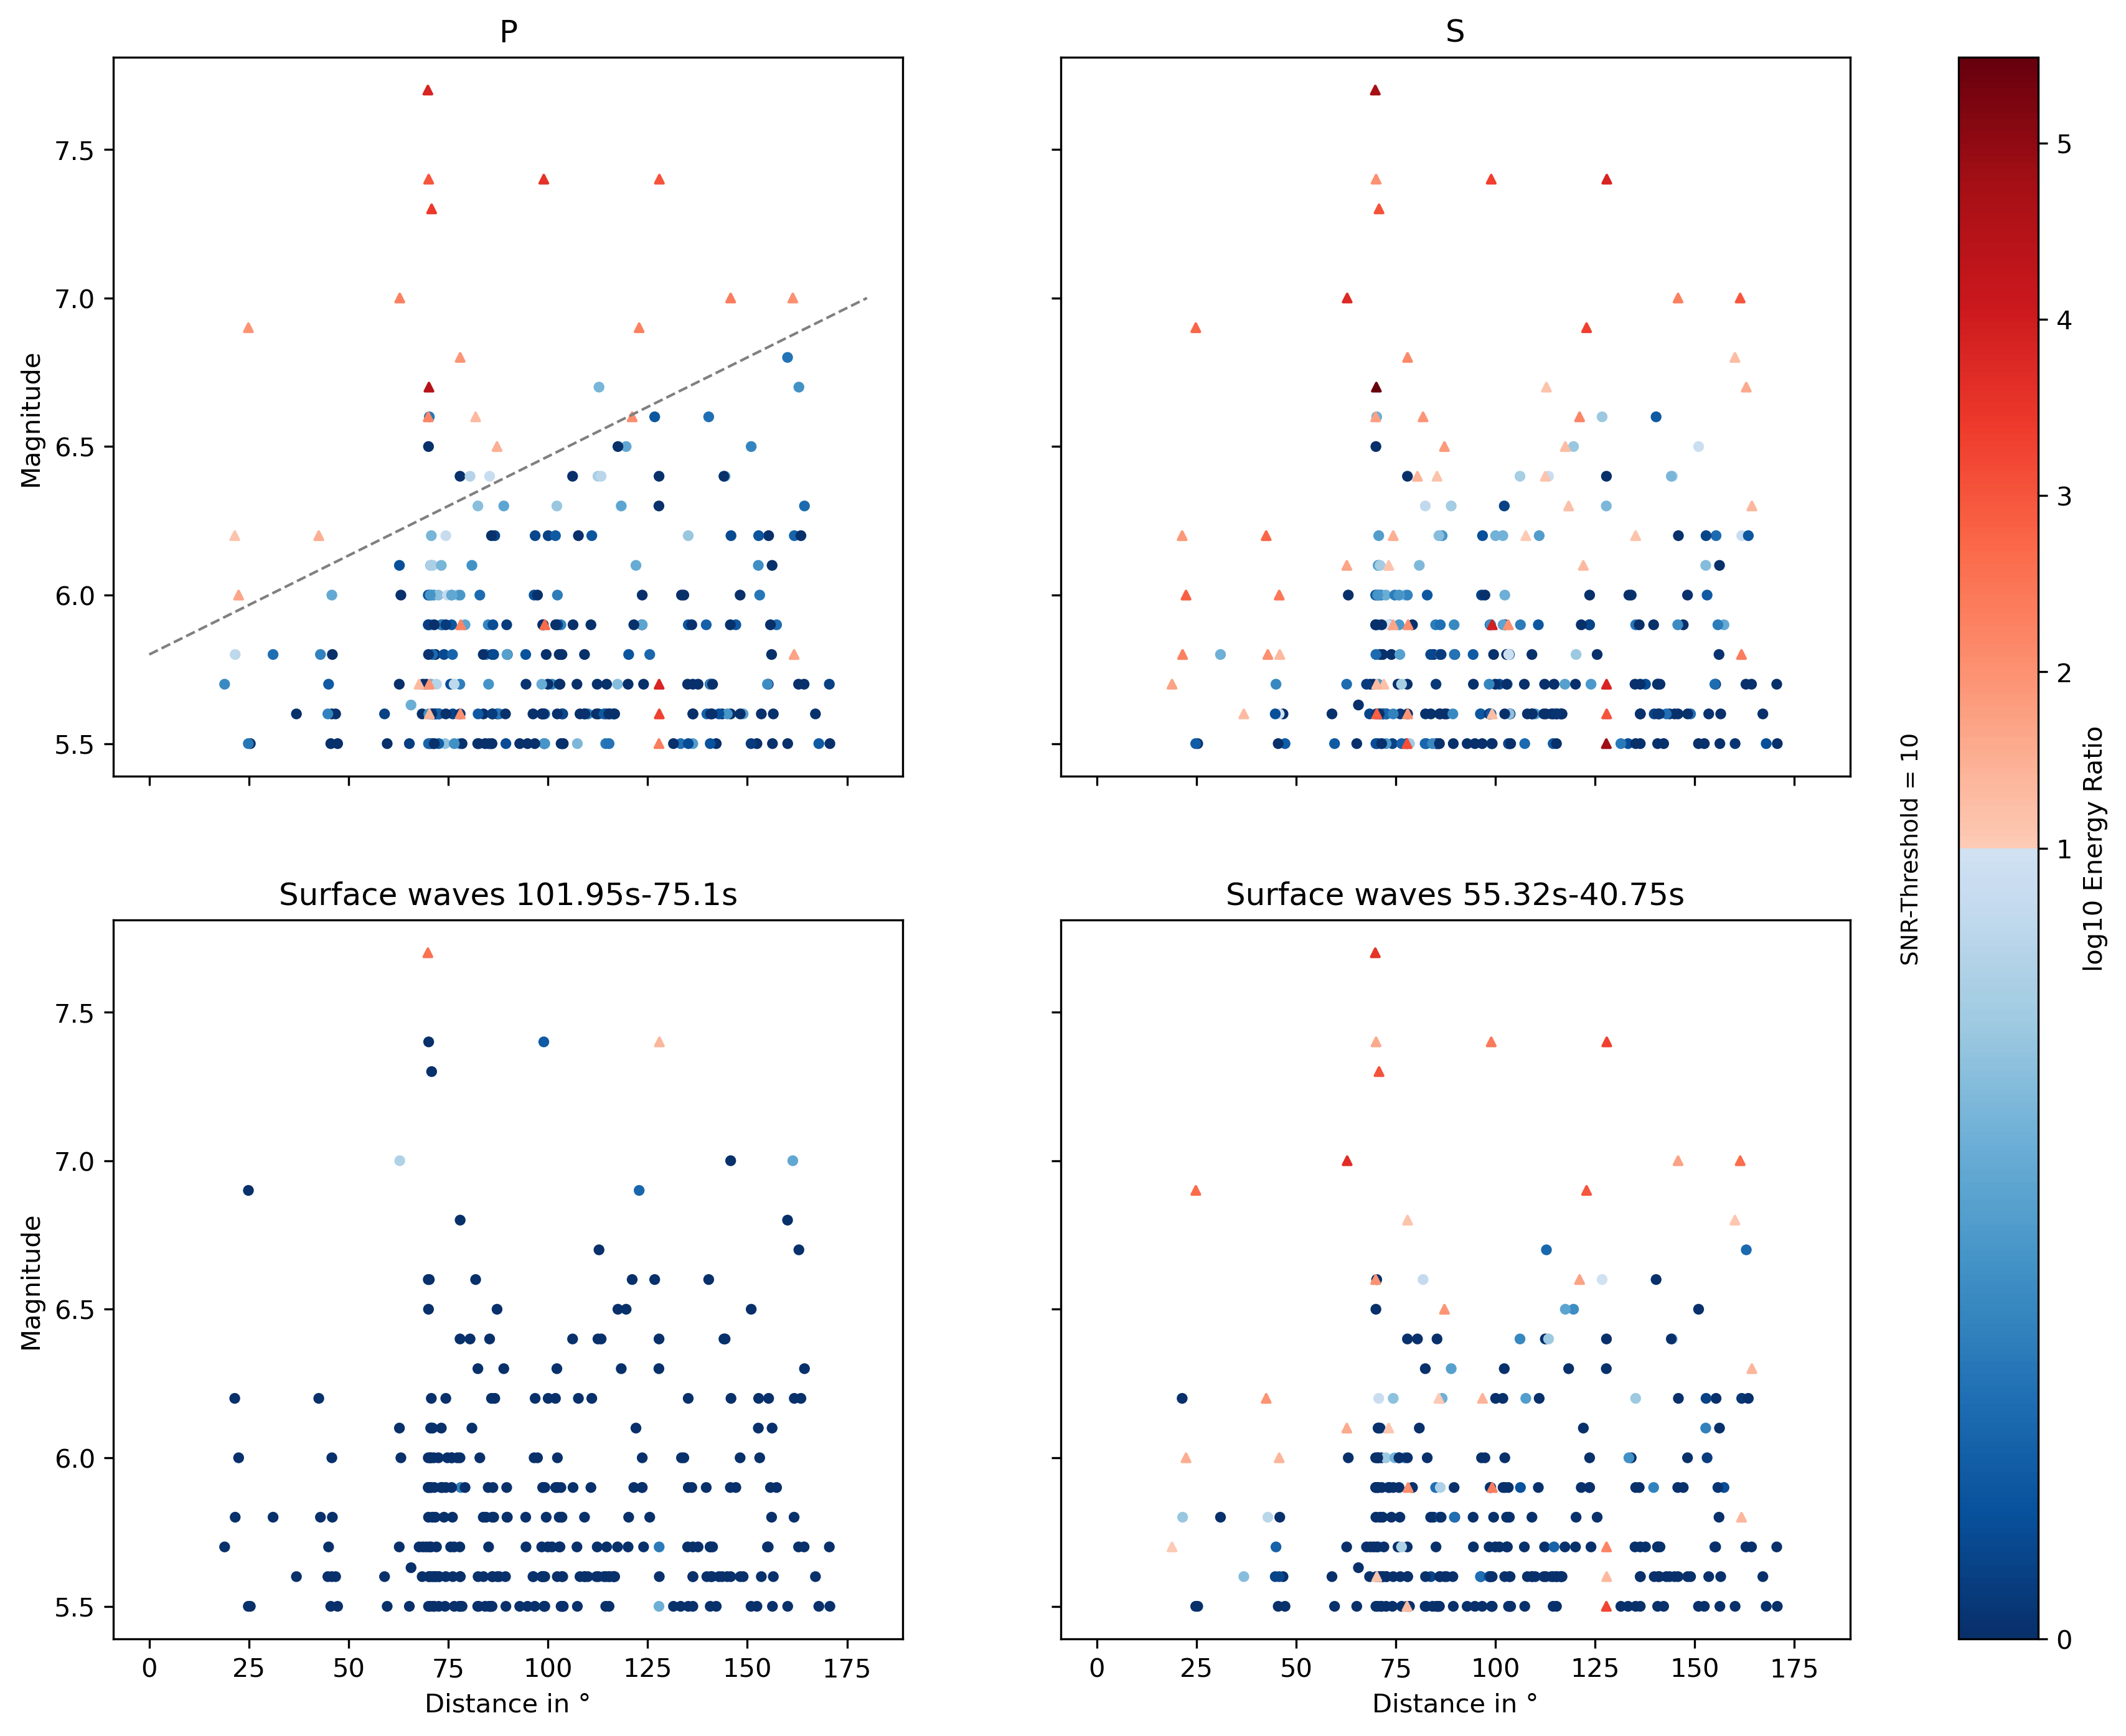

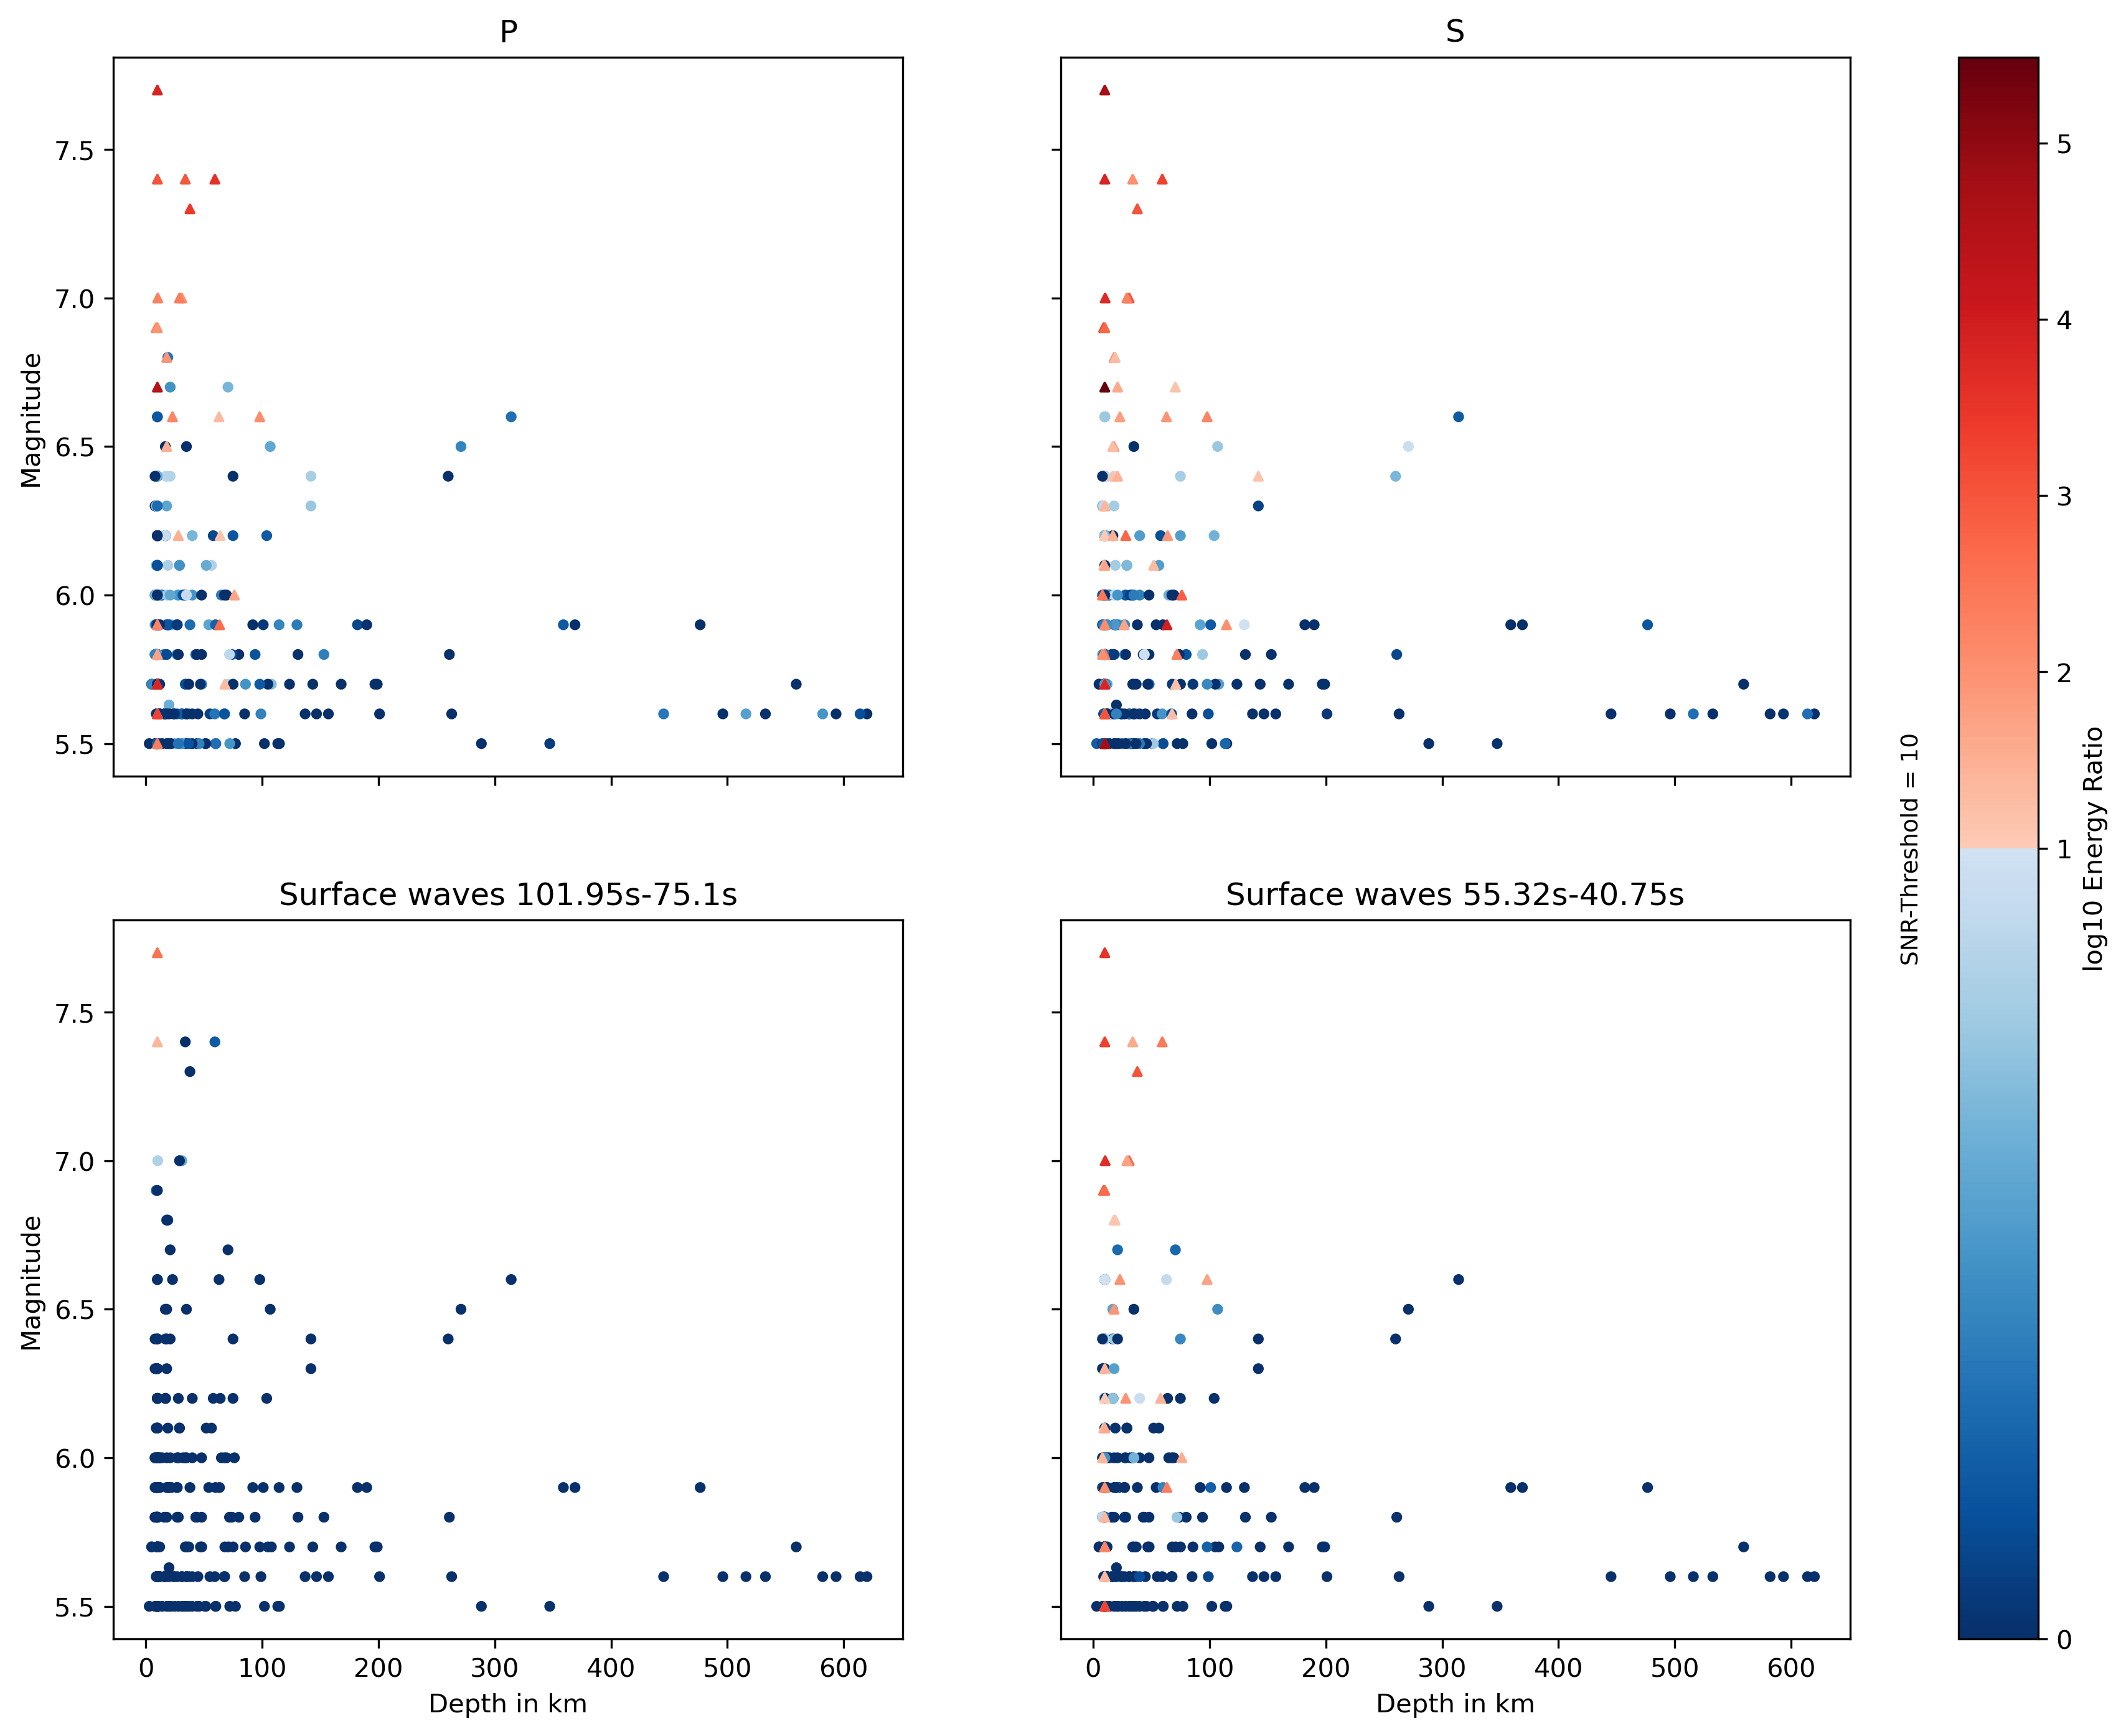

In [33]:
# pandas plots
df["log_energy_P"] = np.log10(df["energy_P"])
df["log_energy_S"] = np.log10(df["energy_S"])
df["log_energy_ratio_P"] = np.log10(df["energy_ratio_P"])
df["log_energy_ratio_S"] = np.log10(df["energy_ratio_S"])
df["log_energy_ratios_Surf_broadNoise0"] = df["energy_ratios_Surf_broadNoise"].apply(lambda x: np.log10(x[band_index0]))
df["log_energy_ratios_Surf_broadNoise1"] = df["energy_ratios_Surf_broadNoise"].apply(lambda x: np.log10(x[band_index1]))
threshold = 10 # ratio as threshold
thresh_log = np.log10(threshold)
point_size = 10
marker = "^"

vmin = df[["log_energy_ratio_P", "log_energy_ratio_S"]].min().min()
vmax = df[["log_energy_ratio_P", "log_energy_ratio_S"]].max().max()

mask_low_P  = df["log_energy_ratio_P"] <= thresh_log
mask_high_P = df["log_energy_ratio_P"] >  thresh_log
mask_low_S  = df["log_energy_ratio_S"] <= thresh_log
mask_high_S = df["log_energy_ratio_S"] >  thresh_log
mask_low_Surf0  = df["log_energy_ratios_Surf_broadNoise0"] <= thresh_log
mask_high_Surf0 = df["log_energy_ratios_Surf_broadNoise0"] >  thresh_log
mask_low_Surf1  = df["log_energy_ratios_Surf_broadNoise1"] <= thresh_log
mask_high_Surf1 = df["log_energy_ratios_Surf_broadNoise1"] >  thresh_log
cmap_low  = plt.cm.Blues(np.linspace(1, 0.2, 128))
cmap_high = plt.cm.Reds(np.linspace(0.2, 1, 128))
cmap = LinearSegmentedColormap.from_list(thresh_log, np.vstack((cmap_low, cmap_high)))

norm = TwoSlopeNorm(vmin=0, vcenter=thresh_log, vmax=vmax)

fig1, axes = plt.subplots(2, 2, figsize=(15,11), dpi=300, sharex=True, sharey=True)
sc1_0 = axes[0][0].scatter(df["distance_deg_P"][mask_low_P], df["magnitude"][mask_low_P], c=df["log_energy_ratio_P"][mask_low_P], s=point_size, cmap=cmap, norm=norm, marker="o")
axes[0][0].scatter(df["distance_deg_P"][mask_high_P], df["magnitude"][mask_high_P], c=df["log_energy_ratio_P"][mask_high_P], s=point_size, cmap=cmap, norm=norm, marker=marker)
axes[0][0].plot([0, 180], [5.8, 7.0], color="grey", linewidth=1, linestyle="--")
axes[0][0].set_title("P")
axes[0][0].set_ylabel("Magnitude")
sc1_1 = axes[0][1].scatter(df["distance_deg_P"][mask_low_S], df["magnitude"][mask_low_S], c=df["log_energy_ratio_S"][mask_low_S], s=point_size, cmap=cmap, norm=norm, marker="o")
axes[0][1].scatter(df["distance_deg_P"][mask_high_S], df["magnitude"][mask_high_S], c=df["log_energy_ratio_S"][mask_high_S], s=point_size, cmap=cmap, norm=norm, marker=marker)
axes[0][1].set_title("S")
sc1_2 = axes[1][0].scatter(df["distance_deg_P"][mask_low_Surf0], df["magnitude"][mask_low_Surf0], c=df["log_energy_ratios_Surf_broadNoise0"][mask_low_Surf0], s=point_size, cmap=cmap, norm=norm)
axes[1][0].scatter(df["distance_deg_P"][mask_high_Surf0], df["magnitude"][mask_high_Surf0], c=df["log_energy_ratios_Surf_broadNoise0"][mask_high_Surf0], s=point_size, cmap=cmap, norm=norm, marker=marker)
axes[1][0].set_title(f"Surface waves {np.round(T_edges[band_index0],2)}s-{np.round(T_edges[band_index0+1], 2)}s")
axes[1][0].set_xlabel("Distance in °")
axes[1][0].set_ylabel("Magnitude")
sc1_3 = axes[1][1].scatter(df["distance_deg_P"][mask_low_Surf1], df["magnitude"][mask_low_Surf1], c=df["log_energy_ratios_Surf_broadNoise1"][mask_low_Surf1], s=point_size, cmap=cmap, norm=norm)
axes[1][1].scatter(df["distance_deg_P"][mask_high_Surf1], df["magnitude"][mask_high_Surf1], c=df["log_energy_ratios_Surf_broadNoise1"][mask_high_Surf1], s=point_size, cmap=cmap, norm=norm, marker=marker)
axes[1][1].set_title(f"Surface waves {np.round(T_edges[band_index1],2)}s-{np.round(T_edges[band_index1+1], 2)}s")
axes[1][1].set_xlabel("Distance in °")
cbar1 = fig1.colorbar(sc1_0, ax=axes, label="log10 Energy Ratio")
cbar1.ax.text(-0.6, 0.5, f"SNR-Threshold = {threshold}", transform=cbar1.ax.transAxes, rotation=90, ha="center", va="center", fontsize=9, color="black")

fig2, axes = plt.subplots(2, 2, figsize=(15,11), dpi=300, sharex=True, sharey=True)
sc2_0 = axes[0][0].scatter(df["origin_depth"][mask_low_P]/1000, df["magnitude"][mask_low_P], c=df["log_energy_ratio_P"][mask_low_P], s=point_size, cmap=cmap, norm=norm, marker="o")
axes[0][0].scatter(df["origin_depth"][mask_high_P]/1000, df["magnitude"][mask_high_P], c=df["log_energy_ratio_P"][mask_high_P], s=point_size, cmap=cmap, norm=norm, marker=marker)
axes[0][0].set_title("P")
axes[0][0].set_ylabel("Magnitude")
sc2_1 = axes[0][1].scatter(df["origin_depth"][mask_low_S]/1000, df["magnitude"][mask_low_S], c=df["log_energy_ratio_S"][mask_low_S], s=point_size, cmap=cmap, norm=norm, marker="o")
axes[0][1].scatter(df["origin_depth"][mask_high_S]/1000, df["magnitude"][mask_high_S], c=df["log_energy_ratio_S"][mask_high_S], s=point_size, cmap=cmap, norm=norm, marker=marker)
axes[0][1].set_title("S")
sc2_2 = axes[1][0].scatter(df["origin_depth"][mask_low_Surf0]/1000, df["magnitude"][mask_low_Surf0], c=df["log_energy_ratios_Surf_broadNoise0"][mask_low_Surf0], s=point_size, cmap=cmap, norm=norm)
axes[1][0].scatter(df["origin_depth"][mask_high_Surf0]/1000, df["magnitude"][mask_high_Surf0], c=df["log_energy_ratios_Surf_broadNoise0"][mask_high_Surf0], s=point_size, cmap=cmap, norm=norm, marker=marker)
axes[1][0].set_title(f"Surface waves {np.round(T_edges[band_index0],2)}s-{np.round(T_edges[band_index0+1], 2)}s")
axes[1][0].set_xlabel("Depth in km")
axes[1][0].set_ylabel("Magnitude")
sc2_3 = axes[1][1].scatter(df["origin_depth"][mask_low_Surf1]/1000, df["magnitude"][mask_low_Surf1], c=df["log_energy_ratios_Surf_broadNoise1"][mask_low_Surf1], s=point_size, cmap=cmap, norm=norm)
axes[1][1].scatter(df["origin_depth"][mask_high_Surf1]/1000, df["magnitude"][mask_high_Surf1], c=df["log_energy_ratios_Surf_broadNoise1"][mask_high_Surf1], s=point_size, cmap=cmap, norm=norm, marker=marker)
axes[1][1].set_title(f"Surface waves {np.round(T_edges[band_index1],2)}s-{np.round(T_edges[band_index1+1], 2)}s")
axes[1][1].set_xlabel("Depth in km")
cbar2 = fig2.colorbar(sc2_0, ax=axes, label="log10 Energy Ratio")
cbar2.ax.text(-0.6, 0.5, f"SNR-Threshold = {threshold}", transform=cbar2.ax.transAxes, rotation=90, ha="center", va="center", fontsize=9, color="black")